In [191]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [192]:
house=pd.read_csv("data/HousePrice.csv")
house.describe()

,Id,MSSubClass,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2918.000000,2918.000000,1460.000000
mean,1459.000000,57.137718,10168.114080,5.564577,1971.312778,1984.264474,49.582248,1051.777587,180921.195890
std,842.787043,42.517628,7886.996359,1.113131,30.291442,20.894344,169.205611,440.766258,79442.502883
min,0.000000,20.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,34900.000000
25%,729.500000,20.000000,7478.000000,5.000000,1953.500000,1965.000000,0.000000,793.000000,129975.000000
50%,1459.000000,50.000000,9453.000000,5.000000,1973.000000,1993.000000,0.000000,989.500000,163000.000000
75%,2188.500000,70.000000,11570.000000,6.000000,2001.000000,2004.000000,0.000000,1302.000000,214000.000000
max,2918.000000,190.000000,215245.000000,9.000000,2010.000000,2010.000000,1526.000000,6110.000000,755000.000000


In [206]:
#CLEANING AND PRE PROCESSING 
house=house.dropna()
house.sample(10)

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
1017,1017,120,1,5814,11,11,5,1984,1984,HdBoard,0.0,1220.0,187500.0
713,713,190,1,9873,0,1,5,1970,1970,HdBoard,0.0,960.0,129000.0
1211,1211,50,1,12134,0,0,7,1988,2005,Wd Sdng,0.0,559.0,164000.0
231,231,60,1,15138,0,0,5,1995,1996,VinylSd,0.0,1462.0,403000.0
275,275,50,1,7264,0,0,7,1925,2007,Wd Sdng,0.0,952.0,205000.0
332,332,20,1,10655,0,0,5,2003,2004,VinylSd,479.0,3206.0,284000.0
871,871,60,1,8750,0,0,5,1998,1998,VinylSd,0.0,804.0,200500.0
803,803,60,1,13891,0,0,5,2008,2009,VinylSd,0.0,1734.0,582933.0
119,119,60,1,8461,0,0,5,2005,2006,VinylSd,0.0,728.0,163990.0
1093,1093,20,1,9230,10,0,8,1965,1998,MetalSd,0.0,864.0,146000.0


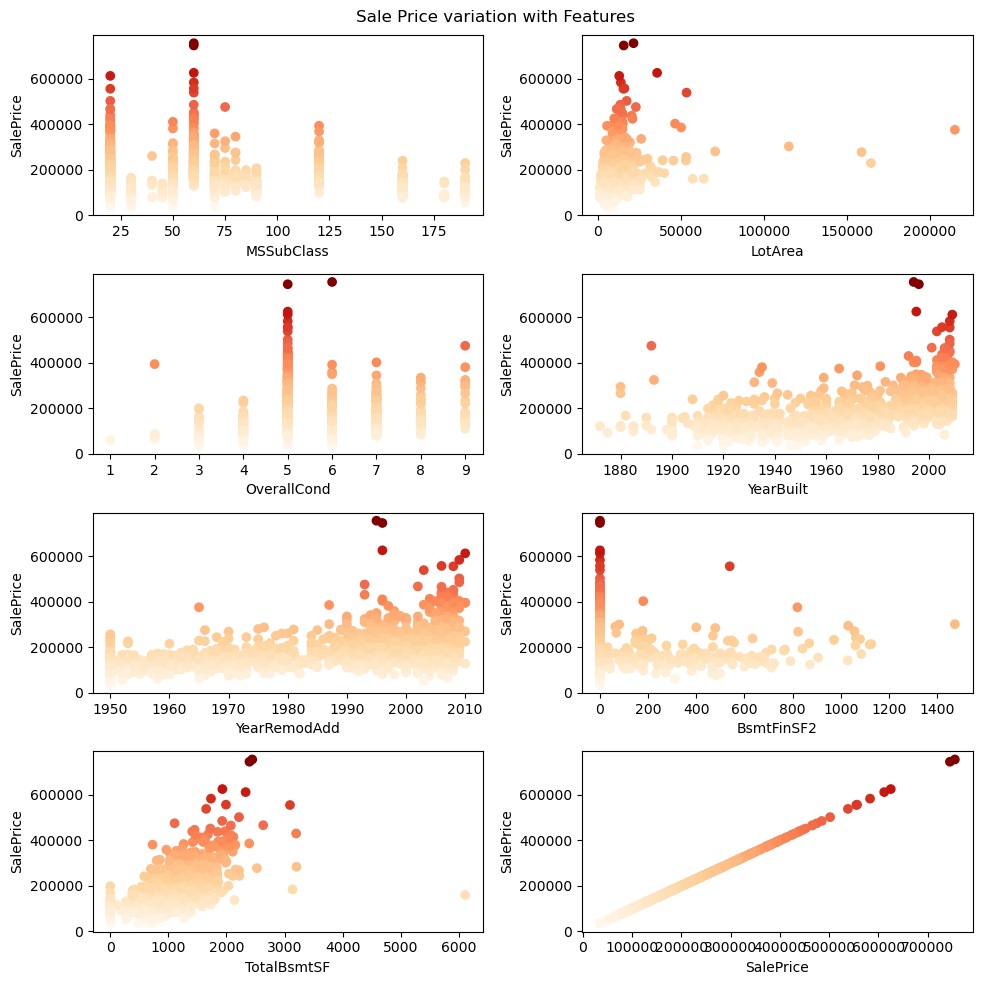

In [207]:
#data vizulaisation of the data using scatter plot
fig,ax=plt.subplots(4,2,figsize=(10,10))
house_plot=house.drop(columns=["Id","MSZoning","LotConfig","BldgType","Exterior1st"])


all_columns=house_plot.columns
index=0
for i in range(4):
    for j in range(2):
        
        ax[i][j].scatter(house[all_columns[index]],
                         house["SalePrice"],
                         cmap="OrRd",
                         c=house["SalePrice"],
                         label=(f"SalePrice vs {all_columns[index]}")
                        )
        ax[i][j].set_xlabel(f"{all_columns[index]}")
        ax[i][j].set_ylabel("SalePrice")
        index=index+1



fig.suptitle("Sale Price variation with Features")
fig.tight_layout()


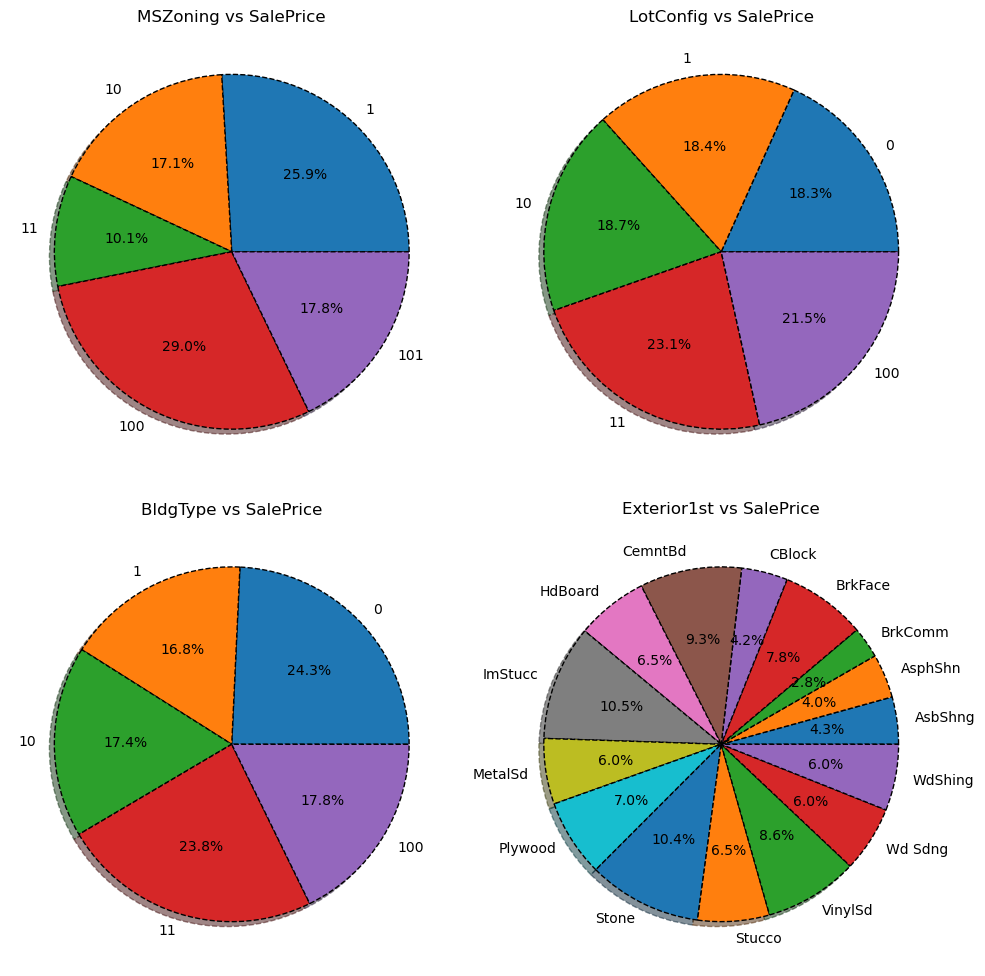

In [208]:
#data vizualisation using pie chart 
fig,ax=plt.subplots(2,2,figsize=(10,10))
pie_col=["MSZoning","LotConfig","BldgType","Exterior1st"]
coun=0
my_colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']
for i in range(2):
    for j in range(2):
        pie_data=house.groupby([pie_col[coun]]).mean("SalePrice")
        ax[i][j].pie(pie_data["SalePrice"],
                labels=pie_data.index,
                autopct="%1.1f%%",
                wedgeprops={
                    "edgecolor":"black",
                    "linewidth":"1",
                    "linestyle":"--"
                },
                shadow=True)
        ax[i][j].set_title(f"{pie_col[coun]} vs SalePrice")
        coun=coun+1

fig.tight_layout()


In [196]:
#preprocessing of the data
a={"RL":1,"RM":10,"C (all)":11,"FV":100,"RH":101,"nan":110}
b={"Inside":0,"FR2":1,"Corner":10,"CulDSac":11,"FR3":100}
c={"1Fam":0,"2fmCon":1,"Duplex":10,"TwnhsE":11,"Twnhs":100}
house["MSZoning"]=house["MSZoning"].map(a)
house["LotConfig"]=house["LotConfig"].map(b)
house["BldgType"]=house["BldgType"].map(c)
house
house.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')

In [198]:
#assigning x and y
X=house.drop(columns=["Id","Exterior1st","SalePrice"])
y=house["SalePrice"]
print(X)
print(y)

      MSSubClass  MSZoning  LotArea  LotConfig  BldgType  OverallCond  \
0             60         1     8450          0         0            5   
1             20         1     9600          1         0            8   
2             60         1    11250          0         0            5   
3             70         1     9550         10         0            5   
4             60         1    14260          1         0            5   
...          ...       ...      ...        ...       ...          ...   
1455          60         1     7917          0         0            5   
1456          20         1    13175          0         0            6   
1457          70         1     9042          0         0            9   
1458          20         1     9717          0         0            6   
1459          20         1     9937          0         0            6   

      YearBuilt  YearRemodAdd  BsmtFinSF2  TotalBsmtSF  
0          2003          2003         0.0        856.0  
1        

In [199]:
X.head()

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF
0,60,1,8450,0,0,5,2003,2003,0.0,856.0
1,20,1,9600,1,0,8,1976,1976,0.0,1262.0
2,60,1,11250,0,0,5,2001,2002,0.0,920.0
3,70,1,9550,10,0,5,1915,1970,0.0,756.0
4,60,1,14260,1,0,5,2000,2000,0.0,1145.0


In [200]:
#train and test spliting
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [201]:
#building model
model=LinearRegression()
model.fit(X_train,Y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [202]:
#predicting values
Y_pred=model.predict(X_test)
print(Y_pred)

[199581.40331482 237348.64623704 118456.74688573 138034.35388154
 261149.24033375 137967.84582654 186765.4146678  113928.18927206
  84274.54613464 143394.69337171 114031.0513491  149096.81865521
 113084.44865122 245425.69963429 199809.96840089 186357.68761942
 199830.07766392 185811.45445964 107501.32802364 239743.47375758
 167868.48298255 206303.33504598 194427.26390657 169989.80515017
 230420.9975597  212171.77385597 235612.91713162 129164.17224524
 200968.04627675 246681.96795172 115877.23300157 213234.04996093
 213572.51766207 142008.29708906 261450.72150113 163875.84849985
 156960.38095123 199634.32933222 239973.26544911  65235.12328988
 109230.4958491  200108.23233515 148074.19148549 293413.54118954
 141914.36818594  82566.37533504 126381.09993139 156457.19798087
 277774.80169674 135069.09249035 124156.67286631 208255.47564318
 125063.51198852 212027.37961364 199768.41816483 264379.6599772
 177117.39466751 187684.66043655 171739.92658181 112762.38050769
  79908.41025755 177842.71

In [203]:
Y_test

892     154500.0
1105    325000.0
413     115000.0
522     159000.0
1036    315500.0
          ...   
479      89471.0
1361    260000.0
802     189000.0
651     108000.0
722     124500.0
Name: SalePrice, Length: 292, dtype: float64

Text(0, 0.5, 'PREDICTED VALUE')

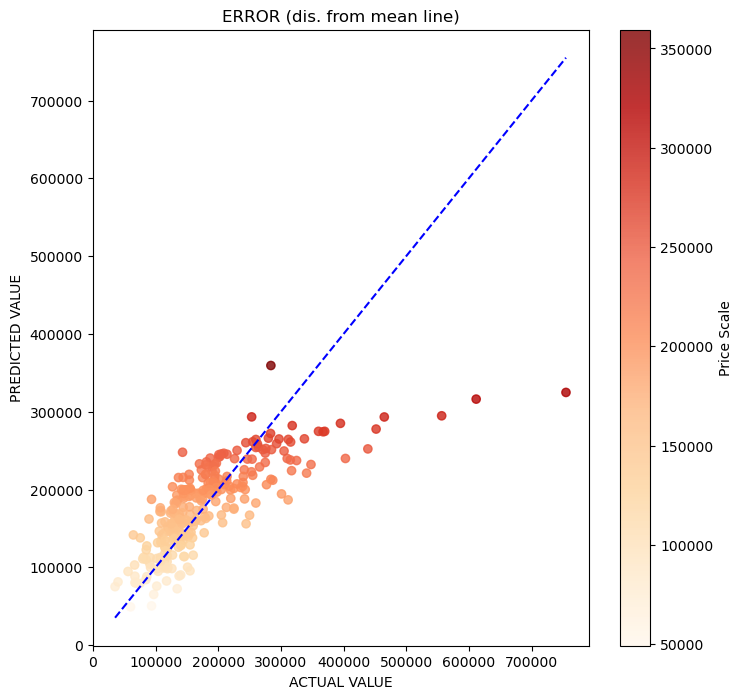

In [209]:
#EXPECTED vs ACTUAL SalePrice data
fig,ax=plt.subplots(figsize=(8,8))

#scatter plot for Y_TEST vs Y_PRED 
sc=ax.scatter(Y_test,Y_pred,cmap="OrRd",
              c=Y_pred,
              label="PREDICTED vs ACTUAL SalePrice",
              alpha=0.8
             )
fig.colorbar(sc,ax=ax,label="Price Scale")

#a line representing how much our value drifted away
min_val=min(min(Y_test),min(Y_pred))
max_val=max(max(Y_test),max(Y_pred))
ax.plot([min_val,max_val],[min_val,max_val],color="blue",linestyle="--",label="PerfectFit")
ax.set_title("ERROR (dis. from mean line)")
ax.set_xlabel("ACTUAL VALUE")
ax.set_ylabel("PREDICTED VALUE")


In [211]:
#evaluation of our model using R-squared metrics
r2=r2_score(Y_test,Y_pred)
print(f"ACCURACY OF PREDICTION : {r2*100}")

ACCURACY OF PREDICTION : 58.43695125863492
